<a href="https://colab.research.google.com/github/nataliareutskada/Python-Projects/blob/main/Python_for_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Python for DA

In [ ]:
# import moduls
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#style for visualization
plt.style.use("bmh")

##1. Data overview

In [ ]:
# connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# changing work folder
%cd /content/drive/MyDrive/Pandas\ exercises/Final\ project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Pandas exercises/Final project


In [ ]:
# uploading first dataset
df_events = pd.read_csv("events.csv")
df_events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


Data description:
1. `Order ID` - unique identifier for each order
2. `Order Date` — date when the order was placed
3. `Ship Date` — date when the order was shipped
4. `Order Priority` — priority level of the order
5. `Country Code` — 3-letter country code of the destination
6. `Product ID` — unique identifier for the product ordered
7. `Sales Channel` — how the sale was made — either Online or Offline
8. `Units Sold` — number of units sold in that order
9. `Unit Price` — selling price per unit (in currency, USD)
10. `Unit Cost` — cost price per unit (in currency, USD)

In [ ]:
# uploading second dataset
df_countries = pd.read_csv("countries.csv")
df_countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


Data description:
1. `name` - country name
2. `alpha-2` — 2-letter country code
3. `alpha-3` — 3-letter country code
4. `region` — broad geographical region
5. `sub-region` — specific geographic area


Data description:
1. `id` - unique product identifier
2. `item_type` — category of the product

In [ ]:
# uploading third dataset
df_products = pd.read_csv("products.csv")
df_products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


**Key** linking fields across the three tables:

*Countries* table `alpha-3` column links to *Events* table `Country Code` column
*Products* table `id` column links to *Events* table `Product ID` column

The *Events* table acts as the central table

##2. Data cleaning

###Events table

In [ ]:
# identify the missing values in `df_events` table
print(f"Missing values in events table:")
print(df_events.isna().sum())

print(f"Percentage of missing values:")
print(df_events.isna().sum() / df_events.shape[0] * 100)

Missing values in events table:
Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
Percentage of missing values:
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
# check datatypes in `df_events` table
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
# Country Code - 82 missing values, which is 6.17%, so can`t be just removed
missing_country = df_events[df_events["Country Code"].isna()]

# total number of orders from missing country
total_orders_missing_country = missing_country["Order ID"].count()

# total revenue from missing country
total_revenue_missing_country = round((missing_country["Units Sold"] * missing_country["Unit Price"]).sum())

# results
print(f"Total number of orders with missing country: {total_orders_missing_country}")
print(f"Total revenue from missing country: {total_revenue_missing_country}$")


Total number of orders with missing country: 82
Total revenue from missing country: 103145647$


In [ ]:
# Units Sold — 2 missing values, which is 0.15%, so removing them
df_events = df_events.dropna(subset="Units Sold")

# remove records containing NaN in the “Country Code” field
df_events = df_events.dropna(subset="Country Code")

# result
df_events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
# changing the type Order ID to object, Order Date & Ship Date to datetime, Units Sold to int, Product ID to object
df_events["Order ID"] = df_events["Order ID"].astype(str)
df_events["Order Date"] = pd.to_datetime(df_events["Order Date"])
df_events["Ship Date"] = pd.to_datetime(df_events["Ship Date"])
df_events["Units Sold"] = df_events["Units Sold"].astype(int)
df_events["Product ID"] = df_events["Product ID"].astype(str)

# result
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   object        
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   object        
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   int64         
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 107.1+ KB


In [ ]:
# renaming columns
df_events.columns = df_events.columns.str.strip().str.lower().str.replace(" ", "_")

# removing extra blank spaces in the dataframe and changing data to lower case
df_events["order_priority"] = df_events["order_priority"].str.strip().str.title()
df_events["country_code"] = df_events["country_code"].str.strip().str.upper()
df_events["sales_channel"] = df_events["sales_channel"].str.strip().str.title()

# result
df_events


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79
5,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220,651.21,524.96
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734,9.33,6.92
1326,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192,47.45,31.79
1327,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574,255.28,159.42
1328,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070,437.20,263.33


In [ ]:
# presence of duplicates in the `df_events` table
duplicate_rows = df_events.duplicated()
print(duplicate_rows)
duplicate_events = duplicate_rows.sum()

#result
print(f"Duplicates found in the table: {duplicate_events}")


0       False
1       False
3       False
4       False
5       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1246, dtype: bool
Duplicates found in the table: 0


In [ ]:
# aggregated statistics
df_events.describe()

,order_date,ship_date,units_sold,unit_price,unit_cost
count,1246,1246,1246.000000,1246.000000,1246.000000
mean,2013-10-11 14:45:15.890850816,2013-11-05 11:46:07.897271296,4953.186998,264.203387,186.310088
min,2010-01-01 00:00:00,2010-01-10 00:00:00,2.000000,9.330000,6.920000
25%,2011-12-09 18:00:00,2011-12-31 12:00:00,2349.250000,81.730000,35.840000
50%,2013-10-14 00:00:00,2013-11-03 00:00:00,4980.000000,154.060000,97.440000
75%,2015-09-01 12:00:00,2015-10-07 18:00:00,7477.000000,433.372500,263.330000
max,2017-07-22 00:00:00,2017-08-31 00:00:00,9999.000000,668.270000,524.960000
std,NaN,NaN,2915.825155,216.592937,175.503652


In [ ]:
# 1 row with units_sold = 9999, possibly
df_events[df_events["units_sold"] == df_events["units_sold"].max()]

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
424,387098824,2013-12-23,2014-01-04,H,GBR,3127,Offline,9999,81.73,56.67


###Countries table

In [ ]:
# identify the missing values in `df_countries` table
print(f"Missing values in `df_countries` table:")
print(df_countries.isna().sum())

print(f"Percentage of missing values:")
print(df_countries.isna().sum() / df_events.shape[0] * 100)

Missing values in `df_countries` table:
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
Percentage of missing values:
name          0.000000
alpha-2       0.080257
alpha-3       0.000000
region        0.080257
sub-region    0.080257
dtype: float64


In [ ]:
# checking for missing values (specification)
df_countries[df_countries.isna().any(axis=1)]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
# replacement of values for Antarctica
df_countries.loc[df_countries["name"] == "Antarctica", ["region", "sub-region"]] = "Antarctic"

# replacement of values for Namibia
df_countries.loc[df_countries["name"] == "Namibia", "alpha-2"] = "Na"

# result
df_countries.isna().sum()

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


In [ ]:
# check datatypes in `df_countries` table
df_countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     249 non-null    object
 2   alpha-3     249 non-null    object
 3   region      249 non-null    object
 4   sub-region  249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
# removing extra blank spaces in the dataframe and changing data to one case
df_countries["name"] = df_countries["name"].str.strip().str.title()
df_countries["alpha-2"] = df_countries["alpha-2"].str.strip().str.upper()
df_countries["alpha-3"] = df_countries["alpha-3"].str.strip().str.upper()
df_countries["region"] = df_countries["region"].str.strip().str.title()
df_countries["sub-region"] = df_countries["sub-region"].str.strip().str.title()

In [ ]:
# presence of duplicates in the `df_countries` table
duplicate_rows = df_countries.duplicated()
print(duplicate_rows)
duplicate_countries = duplicate_rows.sum()

#result
print(f"Duplicates found in the table: {duplicate_countries}")

0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 249, dtype: bool
Duplicates found in the table: 0


In [ ]:
# aggregated statistics
df_countries.describe(include="all")

,name,alpha-2,alpha-3,region,sub-region
count,249,249,249,249,249
unique,249,249,249,6,18
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53


###Producs table

In [ ]:
# identify the missing values in `df_products` table
print(f"Missing values in `df_products` table:")
print(df_products.isna().sum())

Missing values in `df_products` table:
id           0
item_type    0
dtype: int64


In [ ]:
# check datatypes in `df_products` table
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
# changing the type id to object
df_products["id"] = df_products["id"].astype(str)

# result
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     object
 1   item_type  12 non-null     object
dtypes: object(2)
memory usage: 324.0+ bytes


In [ ]:
# removing extra blank spaces in the dataframe and changing data to one case
df_products["id"] = df_products["id"].str.strip()
df_products["item_type"] = df_products["item_type"].str.strip().str.title()

In [ ]:
# presence of duplicates in the `df_products` table
duplicate_rows = df_products.duplicated()
print(duplicate_rows)
duplicate_products = duplicate_rows.sum()

#result
print(f"Duplicates found in the table: {duplicate_products}")

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool
Duplicates found in the table: 0


In [ ]:
# aggregated statistics
df_products.describe(include="all")

,id,item_type
count,12,12
unique,12,12
top,2103,Cereal
freq,1,1


##3. Data analysis and visualization

In [ ]:
# events & countries
df = pd.merge(df_events, df_countries,
                     left_on="country_code",
                     right_on="alpha-3",
                     how="left")
# df & products
df = pd.merge(df, df_products,
              left_on="product_id",
              right_on="id",
              how="left")

# result
df

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,name,alpha-2,alpha-3,region,sub-region,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe,2103,Cereal
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe,2455,Clothes
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe,1270,Beverages
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220,651.21,524.96,Slovakia,SK,SVK,Europe,Eastern Europe,8681,Office Supplies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734,9.33,6.92,Sweden,SE,SWE,Europe,Northern Europe,4594,Fruits
1242,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192,47.45,31.79,Italy,IT,ITA,Europe,Southern Europe,1270,Beverages
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574,255.28,159.42,Russia,RU,RUS,Europe,Eastern Europe,7331,Baby Food
1244,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070,437.20,263.33,Malta,MT,MLT,Europe,Southern Europe,8293,Cosmetics


In [ ]:
# removing unnecessary columns
df = df.drop(columns=["alpha-2", "alpha-3", "id"])

#result
df

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,name,region,sub-region,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220,651.21,524.96,Slovakia,Europe,Eastern Europe,Office Supplies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734,9.33,6.92,Sweden,Europe,Northern Europe,Fruits
1242,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192,47.45,31.79,Italy,Europe,Southern Europe,Beverages
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574,255.28,159.42,Russia,Europe,Eastern Europe,Baby Food
1244,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070,437.20,263.33,Malta,Europe,Southern Europe,Cosmetics


In [ ]:
# check missing values
df.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
order_priority,0
country_code,0
product_id,0
sales_channel,0
units_sold,0
unit_price,0
unit_cost,0


In [ ]:
# rename columns
df = df.rename(columns={"name": "country_name", "item_type": "category", "sub-region": "sub_region"})

# result
df

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,region,sub_region,category
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220,651.21,524.96,Slovakia,Europe,Eastern Europe,Office Supplies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734,9.33,6.92,Sweden,Europe,Northern Europe,Fruits
1242,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192,47.45,31.79,Italy,Europe,Southern Europe,Beverages
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574,255.28,159.42,Russia,Europe,Eastern Europe,Baby Food
1244,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070,437.20,263.33,Malta,Europe,Southern Europe,Cosmetics


###Key performance indicators

In [ ]:
# number of orders
number_orders = df["order_id"].count()

# revenue
df["revenue"] = df["units_sold"] * df["unit_price"]
revenue_cnt = round(df["revenue"].sum())

# profit
df["profit"] = df["units_sold"] * (df["unit_price"] - df["unit_cost"])
profit_cnt = round(df["profit"].sum())

# units sold
units_sold_cnt = df["units_sold"].sum()

# number of countries covered
unique_countries_cnt = df["country_name"].nunique()

# number of unique products
unique_products_cnt = df["product_id"].nunique()

# average order value
avg_order_value = round(df["revenue"].mean())

# profit margin
profit_margin = round((profit_cnt / revenue_cnt) * 100, 2)

# total reveune
total_reveune_all = revenue_cnt + total_revenue_missing_country


# results
print(f"Number of orders: {number_orders}")
print(f"Revenue: {revenue_cnt}$")
print(f"Profit: {profit_cnt}$")
print(f"Units sold: {units_sold_cnt}")
print(f"Number of countries covered: {unique_countries_cnt}")
print(f"Number of unique products: {unique_products_cnt}")
print(f"Average order value: {avg_order_value}$")
print(f"Profit margin: {profit_margin}%\n")

print(f"Total revenue with missing country: {total_reveune_all}$")

Number of orders: 1246
Revenue: 1598983761$
Profit: 473709035$
Units sold: 6171671
Number of countries covered: 45
Number of unique products: 12
Average order value: 1283294$
Profit margin: 29.63%

Total revenue with missing country: 1702129408$


In [ ]:
# data frame after adding revenue	& profit
df

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,region,sub_region,category,revenue,profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal,133705.00,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal,409960.10,176559.87
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes,127966.88,85998.24
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages,362897.60,119767.68
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220,651.21,524.96,Slovakia,Europe,Eastern Europe,Office Supplies,1445686.20,280275.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734,9.33,6.92,Sweden,Europe,Northern Europe,Fruits,44168.22,11408.94
1242,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192,47.45,31.79,Italy,Europe,Southern Europe,Beverages,246360.40,81306.72
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574,255.28,159.42,Russia,Europe,Eastern Europe,Baby Food,146530.72,55023.64
1244,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070,437.20,263.33,Malta,Europe,Southern Europe,Cosmetics,905004.00,359910.90


###Sales by product category

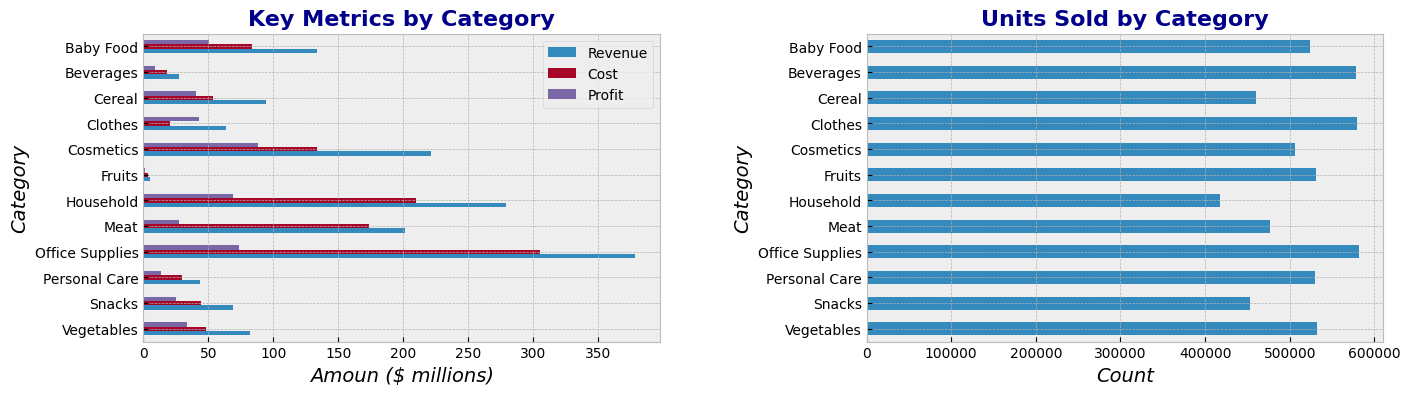

In [ ]:
# cost by category
df["cost"] = df["units_sold"] * df["unit_cost"]

# create a figure with 1 rows and 2 columns of subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 4))


# first subplot - key metrics by category
category_stats = df.groupby("category")[["revenue", "cost", "profit"]].sum().sort_index(ascending=False)
category_stats = category_stats / 1e6
category_stats.plot(kind="barh", ax=ax[0])

ax[0].set_title("Key Metrics by Category", fontsize=16, fontweight="bold", color="darkblue")
ax[0].set_xlabel("Amoun ($ millions)", fontsize=14, fontstyle="italic")
ax[0].set_ylabel("Category", fontsize=14, fontstyle="italic")
ax[0].legend(["Revenue", "Cost", "Profit"])

# second subplot - units by category
df.groupby("category")["units_sold"].sum().sort_index(ascending=False).plot(kind="barh", ax=ax[1])
ax[1].set_title("Units Sold by Category", fontsize=16, fontweight="bold", color="darkblue")
ax[1].set_xlabel("Count", fontsize=14, fontstyle="italic")
ax[1].set_ylabel("Category", fontsize=14, fontstyle="italic")

# show plots
plt.subplots_adjust(wspace=0.4)
plt.show()


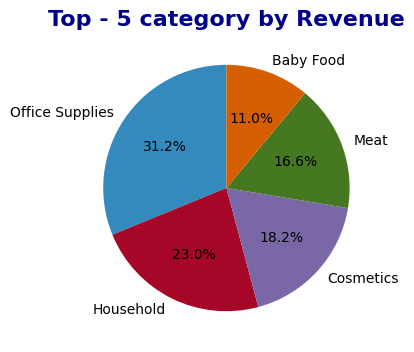

In [ ]:
# identify the top-selling categories
top_categories = df.groupby("category")["revenue"].sum().nlargest(5)
plt.figure(figsize=(4, 4))
top_categories.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    legend=False,
    ylabel=""
)
plt.title("Top - 5 category by Revenue", fontsize=16, fontweight="bold", color="darkblue")

# show plot
plt.show()




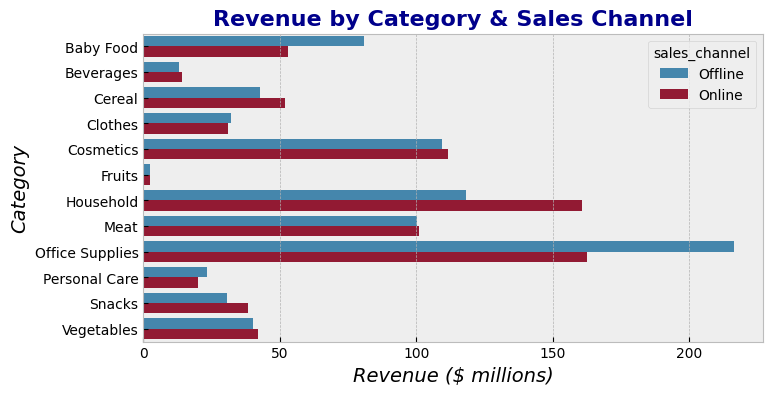

In [ ]:
# grouping by category & sales channel
pivot = df.groupby(["category", "sales_channel"])["revenue"].sum().reset_index()
pivot["revenue"] = pivot["revenue"] / 1e6

plt.subplots(figsize=(8, 4))
sns.barplot(data=pivot, x="revenue", y="category", hue="sales_channel")
plt.title("Revenue by Category & Sales Channel", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Revenue ($ millions)", fontsize=14, fontstyle="italic")
plt.ylabel("Category", fontsize=14, fontstyle="italic")

# show plot
plt.show()


###Sales by regions and countries


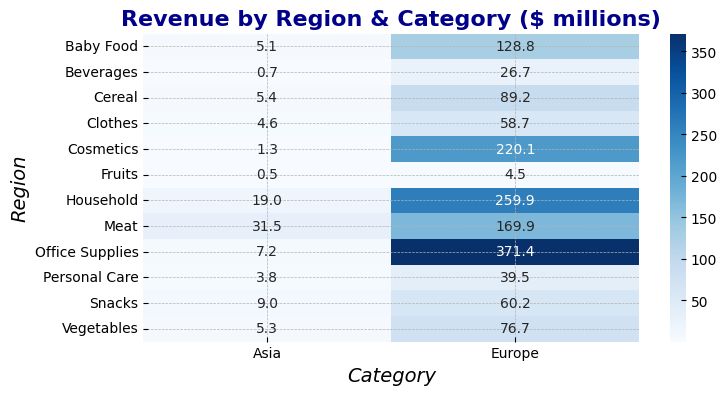

In [ ]:
# pivot table by category and region
pivot_category_region_revenue = df.pivot_table(index="category", columns="region", values="revenue", aggfunc="sum")

plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_category_region_revenue / 1e6, annot=True, fmt=".1f", cmap="Blues")
plt.title("Revenue by Region & Category ($ millions)", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Category", fontsize=14, fontstyle="italic")
plt.ylabel("Region", fontsize=14, fontstyle="italic")

# show plot
plt.show()

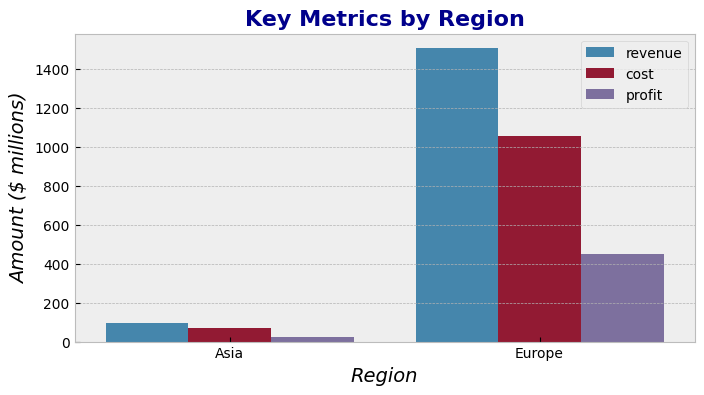

In [ ]:
# key metrics by region
region_stats = df.groupby("region")[["revenue", "cost", "profit"]].sum().reset_index()
region_stats[["revenue", "cost", "profit"]] = region_stats[["revenue", "cost", "profit"]] / 1e6

region_melted = region_stats.melt(id_vars="region",
                                   var_name="metric",
                                   value_name="amount")
plt.subplots(figsize=(8, 4))
sns.barplot(data=region_melted, x="region", y="amount", hue="metric")

plt.title("Key Metrics by Region", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Region", fontsize=14, fontstyle="italic")
plt.ylabel("Amount ($ millions)", fontsize=14, fontstyle="italic")

plt.legend()

# show plot
plt.show()

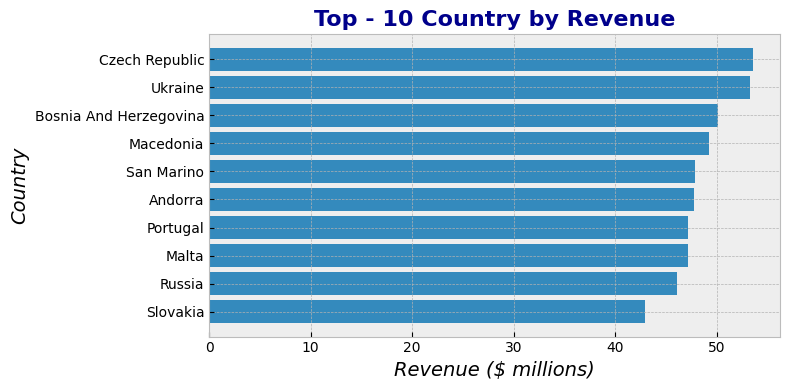

In [ ]:
# identify the 10 top-selling countries
top_country_name = df.groupby("country_name")["revenue"].sum().nlargest(10).sort_values(ascending=True)
top_country_name = top_country_name / 1e6

plt.figure(figsize=(8, 4))
plt.barh(top_country_name.index, top_country_name.values)
plt.xlabel("Revenue ($ millions)", fontsize=14, fontstyle="italic")
plt.ylabel("Country", fontsize=14, fontstyle="italic")
plt.title("Top - 10 Country by Revenue", fontsize=16, fontweight="bold", color="darkblue")
plt.tight_layout()

# show plot
plt.show()

###Sales by channel

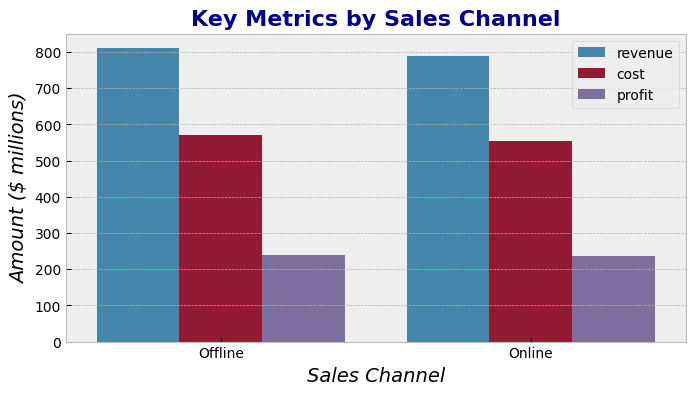

In [ ]:
# key metrics by sales channel
channel_stats = df.groupby("sales_channel")[["revenue", "cost", "profit"]].sum().reset_index()
channel_stats[["revenue", "cost", "profit"]] = channel_stats[["revenue", "cost", "profit"]] / 1e6

channel_melted = channel_stats.melt(id_vars="sales_channel",
                                   var_name="metric",
                                   value_name="amount")
plt.subplots(figsize=(8, 4))
sns.barplot(data=channel_melted, x="sales_channel", y="amount", hue="metric")

plt.title("Key Metrics by Sales Channel", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Sales Channel", fontsize=14, fontstyle="italic")
plt.ylabel("Amount ($ millions)", fontsize=14, fontstyle="italic")

plt.legend()
plt.show()

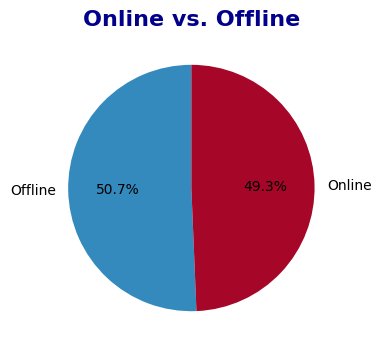

In [ ]:
# online vs. offline share of total revenue
group_sales_channel = df.groupby("sales_channel")["revenue"].sum()
plt.figure(figsize=(4, 4))
group_sales_channel.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    legend=False,
    ylabel=""
)
plt.title("Online vs. Offline", fontsize=16, fontweight="bold", color="darkblue")

# show plot
plt.show()

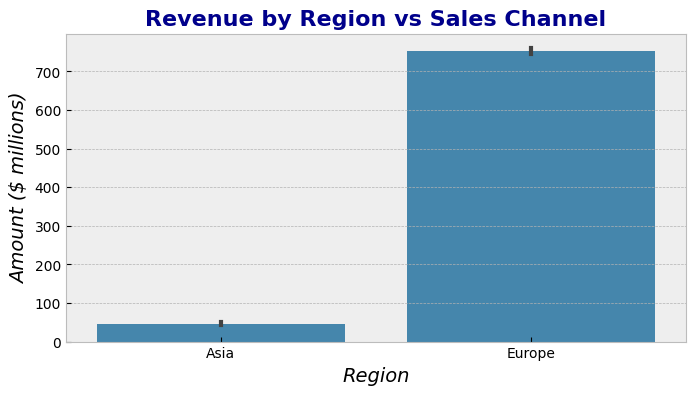

In [ ]:
# revenue by region and sales channel
region_stats = df.groupby(["sales_channel", "region"])["revenue"].sum()
region_stats = (region_stats / 1e6).reset_index()


plt.subplots(figsize=(8, 4))
sns.barplot(data=region_stats, x="region", y="revenue")

plt.title("Revenue by Region vs Sales Channel", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Region", fontsize=14, fontstyle="italic")
plt.ylabel("Amount ($ millions)", fontsize=14, fontstyle="italic")

# show plot
plt.show()

###Sales based on the time interval between order and shipment

In [ ]:
# calculation of the interval in days
df["days_to_ship"] = (df["ship_date"] - df["order_date"]).dt.days
df

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,region,sub_region,category,revenue,profit,cost,days_to_ship
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal,133705.00,57583.50,76121.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal,409960.10,176559.87,233400.23,0
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes,127966.88,85998.24,41968.64,31
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages,362897.60,119767.68,243129.92,38
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220,651.21,524.96,Slovakia,Europe,Eastern Europe,Office Supplies,1445686.20,280275.00,1165411.20,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734,9.33,6.92,Sweden,Europe,Northern Europe,Fruits,44168.22,11408.94,32759.28,3
1242,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192,47.45,31.79,Italy,Europe,Southern Europe,Beverages,246360.40,81306.72,165053.68,28
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574,255.28,159.42,Russia,Europe,Eastern Europe,Baby Food,146530.72,55023.64,91507.08,2
1244,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070,437.20,263.33,Malta,Europe,Southern Europe,Cosmetics,905004.00,359910.90,545093.10,18


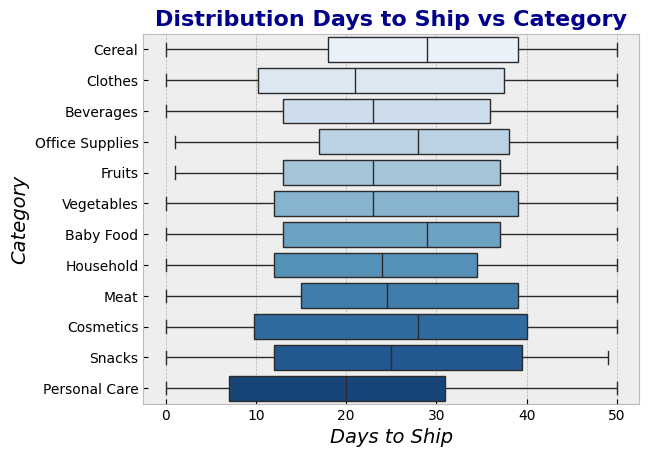

In [ ]:
# distribution days to ship vs category
sns.boxplot(data=df, x="days_to_ship", y="category", hue="category", legend=False, palette="Blues")
plt.title("Distribution Days to Ship vs Category", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Days to Ship", fontsize=14, fontstyle="italic")
plt.ylabel("Category", fontsize=14, fontstyle="italic")

# show plot
plt.show()

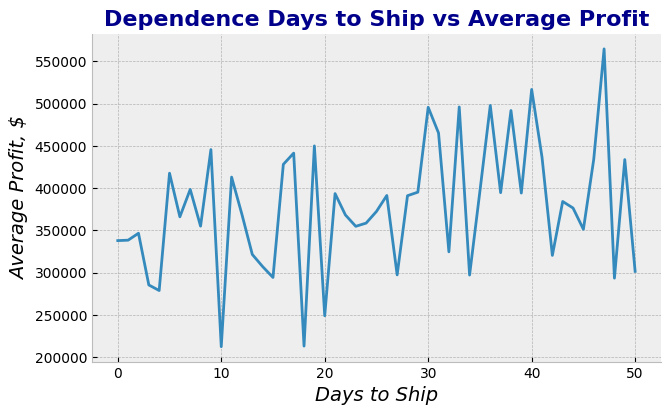

In [ ]:
# grouping by days to ship & profit
shipping_stats = df.groupby("days_to_ship")["profit"].mean().reset_index()

sns.relplot(data=shipping_stats, x="days_to_ship", y="profit", kind="line", height=4, aspect=1.7)
plt.title("Dependence Days to Ship vs Average Profit", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Days to Ship", fontsize=14, fontstyle="italic")
plt.ylabel("Average Profit, $", fontsize=14, fontstyle="italic")

# show plot
plt.show()

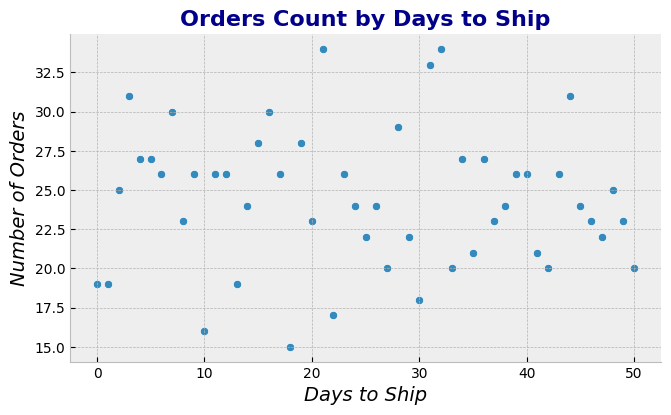

In [ ]:
# dependence orders & days to ship
shipping_counts = df.groupby("days_to_ship")["order_id"].count().reset_index()
# rename columns
shipping_counts = shipping_counts.rename(columns={"order_id": "orders_count"})
shipping_counts

sns.relplot(data=shipping_counts, x="days_to_ship", y="orders_count", height=4, aspect=1.7)
plt.title("Orders Count by Days to Ship", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Days to Ship", fontsize=14, fontstyle="italic")
plt.ylabel("Number of Orders", fontsize=14, fontstyle="italic")

# show plot
plt.show()

###Sales trends (over time)

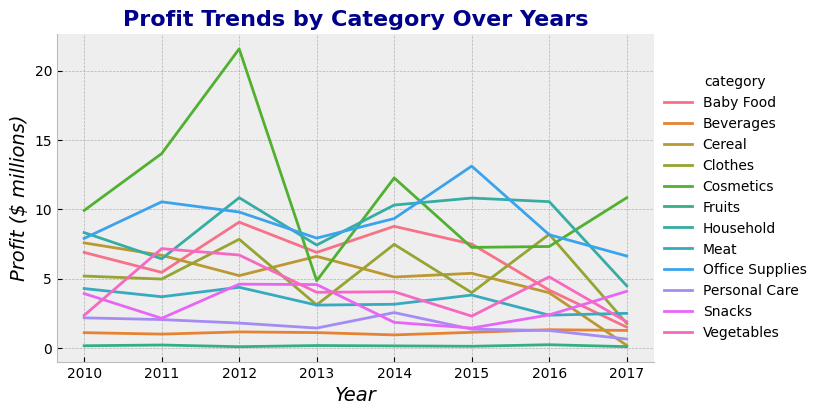

In [ ]:
# profit trends by category
df["order_year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

category_year = df.groupby(["order_year", "category"])["profit"].sum().reset_index()
category_year["profit"] = category_year["profit"] / 1e6

# line chart
sns.relplot(data=category_year, x="order_year", y="profit",
            hue="category", kind="line", height=4, aspect=1.7)

plt.title("Profit Trends by Category Over Years", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Year", fontsize=14, fontstyle="italic")
plt.ylabel("Profit ($ millions)", fontsize=14, fontstyle="italic")

# show plot
plt.show()

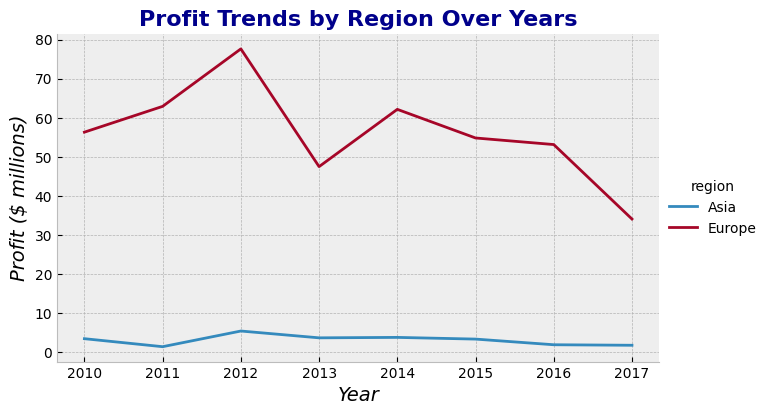

In [ ]:
# regional trends by years
region_year = df.groupby(["order_year", "region"])["profit"].sum().reset_index()
region_year["profit"] = region_year["profit"] / 1e6

# line chart
sns.relplot(data=region_year, x="order_year", y="profit",
            hue="region", kind="line", height=4, aspect=1.7)

plt.title("Profit Trends by Region Over Years", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Year", fontsize=14, fontstyle="italic")
plt.ylabel("Profit ($ millions)", fontsize=14, fontstyle="italic")

# show plot
plt.show()

In [ ]:
# trends by top 10 countries - find countries
top_10_countries = df.groupby("country_name")["profit"].sum().nlargest(10).index
top_10_countries



Index(['Andorra', 'Ukraine', 'Malta', 'San Marino', 'Hungary', 'Macedonia',
       'Czech Republic', 'Russia', 'Bosnia And Herzegovina', 'Greece'],
      dtype='object', name='country_name')

In [ ]:
custom_regions = df[df["country_name"].isin(top_10_countries)]
custom_regions

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,region,sub_region,category,revenue,profit,cost,days_to_ship,order_year,month
21,113524663,2010-10-29,2010-12-09,L,RUS,8293,Online,3325,437.20,263.33,Russia,Europe,Eastern Europe,Cosmetics,1453690.00,578117.75,875572.25,41,2010,10
22,114954173,2010-02-03,2010-02-11,C,MLT,4594,Offline,6349,9.33,6.92,Malta,Europe,Southern Europe,Fruits,59236.17,15301.09,43935.08,8,2010,2
23,115363156,2015-12-04,2016-01-10,H,UKR,8681,Offline,7376,651.21,524.96,Ukraine,Europe,Eastern Europe,Office Supplies,4803324.96,931220.00,3872104.96,37,2015,12
25,118659913,2014-08-02,2014-08-17,C,CZE,2103,Online,2960,205.70,117.11,Czech Republic,Europe,Eastern Europe,Cereal,608872.00,262226.40,346645.60,15,2014,8
29,121380746,2016-11-21,2016-12-18,C,MLT,4594,Online,8115,9.33,6.92,Malta,Europe,Southern Europe,Fruits,75712.95,19557.15,56155.80,27,2016,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1233,988614022,2010-11-28,2011-01-11,L,MKD,2103,Offline,1713,205.70,117.11,Macedonia,Europe,Southern Europe,Cereal,352364.10,151754.67,200609.43,44,2010,11
1234,989403665,2015-04-22,2015-05-25,M,MKD,2455,Online,5386,109.28,35.84,Macedonia,Europe,Southern Europe,Clothes,588582.08,395547.84,193034.24,33,2015,4
1240,994406735,2015-06-07,2015-06-30,M,MLT,1270,Online,5906,47.45,31.79,Malta,Europe,Southern Europe,Beverages,280239.70,92487.96,187751.74,23,2015,6
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574,255.28,159.42,Russia,Europe,Eastern Europe,Baby Food,146530.72,55023.64,91507.08,2,2010,9


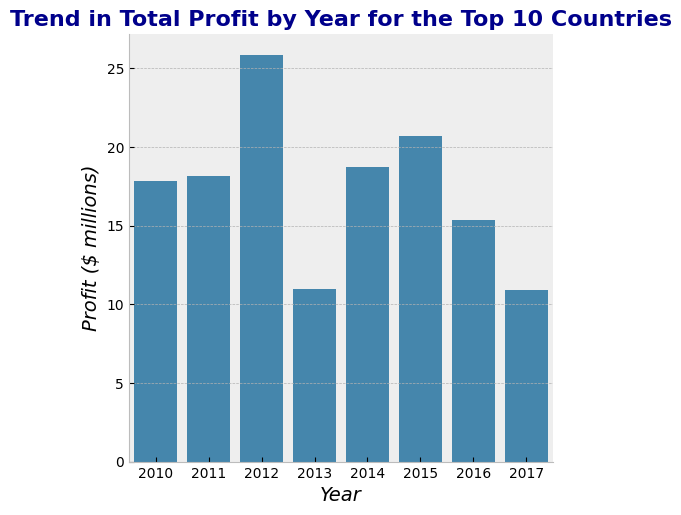

In [ ]:
# top 10 countries trends by years

trend = custom_regions.groupby("order_year")["profit"].sum().reset_index()
trend["profit"] = trend["profit"] / 1e6
cat = sns.catplot(data=trend, x="order_year", y="profit", kind="bar", legend=False)

plt.title("Trend in Total Profit by Year for the Top 10 Countries", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Year", fontsize=14, fontstyle="italic")
plt.ylabel("Profit ($ millions)", fontsize=14, fontstyle="italic")

# show plot
plt.show()

###Analysis of product sales by day of the week

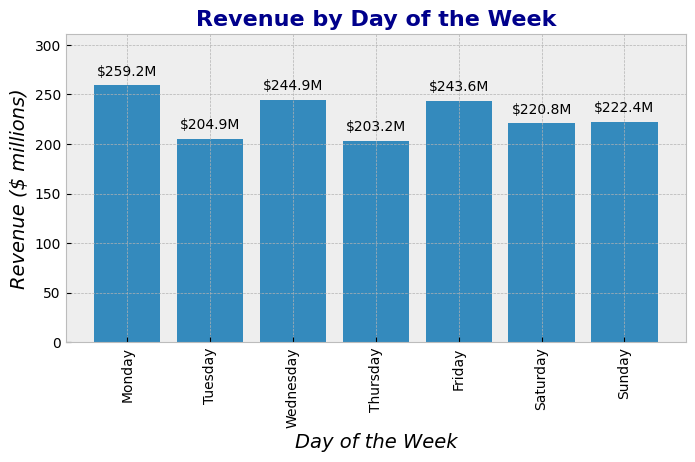

In [ ]:
# extract day of the week from order_date
df["day_of_week"] = df["order_date"].dt.day_name()

plt.subplots(figsize=(8, 4))
day_of_week_sales = df.groupby("day_of_week")["revenue"].sum() / 1e6

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_of_week_sales = day_of_week_sales.reindex(days_order)

bars = plt.bar(day_of_week_sales.index, day_of_week_sales.values)

plt.bar_label(bars, fmt="$%.1fM", fontsize=10, padding=5)
plt.title("Revenue by Day of the Week", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Day of the Week", fontsize=14, fontstyle="italic")
plt.ylabel("Revenue ($ millions)", fontsize=14, fontstyle="italic")

plt.xticks(rotation=90)
plt.ylim(top=day_of_week_sales.values.max() * 1.2)

# show plot
plt.show()

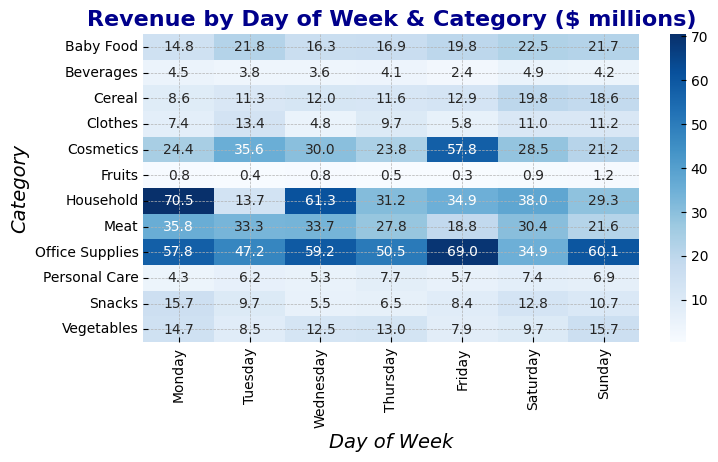

In [ ]:
# analysis of sales by day of the week
pivot_day_category_revenue = pd.pivot_table(df, values="revenue", index="category", columns="day_of_week", aggfunc="sum")
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_day_category_revenue = pivot_day_category_revenue[days_order]

plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_day_category_revenue / 1e6, annot=True, fmt=".1f", cmap="Blues")
plt.title("Revenue by Day of Week & Category ($ millions)", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Day of Week", fontsize=14, fontstyle="italic")
plt.ylabel("Category", fontsize=14, fontstyle="italic")

# show plot
plt.show()

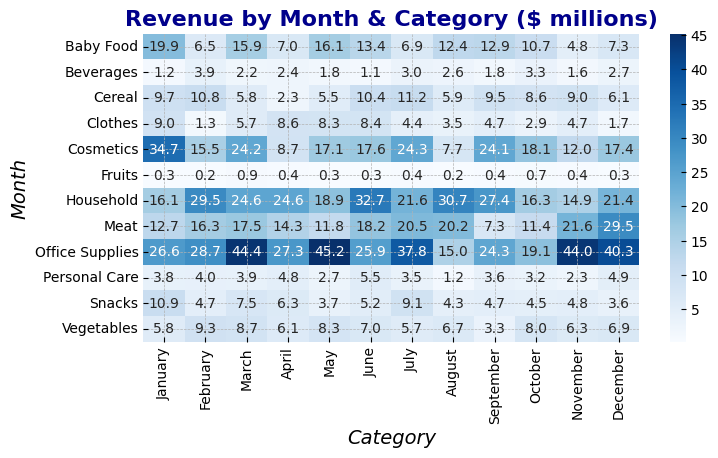

In [ ]:
# analysis of sales by month
df["month"] = df["order_date"].dt.month_name()

pivot_moth_category_revenue = pd.pivot_table(df, values="revenue", index="category", columns="month", aggfunc="sum")
months_order = ["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"]
pivot_moth_category_revenue = pivot_moth_category_revenue[months_order]

plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_moth_category_revenue / 1e6, annot=True, fmt=".1f", cmap="Blues")
plt.title("Revenue by Month & Category ($ millions)", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Category", fontsize=14, fontstyle="italic")
plt.ylabel("Month", fontsize=14, fontstyle="italic")

# show plot
plt.show()

##Reporting
1. *General values*
* **Total revenue** with missing country: **1702129408**\$
2. *General anomalies:* there are missing values—to avoid skewing the data, these have not been included in the analysis
* Number of orders: 1246
* Revenue: 1598983761\$
* Profit: 473709035\$
* Units sold: 6171671
* Number of countries covered: 45
* Number of unique products: 12
* Average order value: 1283294\$
* Profit margin: 29.63%
3. *Regions*
*   Europe generates the majority of revenue, but has lower profit margins
*   Asia has more stable profits, although revenue is lower
*   **Pay attention** to the Asian region and Europe should be **optimized**
4. *Sales Channels*
* Online and offline sales are roughly **equal**
* Neither has a major advantage over the other
5. *Countries*
* Top countries by revenue:
    Czech Republic, Ukraine, Bosnia and Herzegovina, Macedonia and others
* An economic downturn since 2015
* The data shows that sales are **strongly dependent** on Europe
6. *Shipping:*
50-day shipping time is too long; explore how it can be **optimized**
7. *Product Range*
* **Scale**: Office Supplies (core category)
* **Review**: Fruits (low performance)
* **Optimize**: Household (better to target online)
8. *Inventory Management*
* Expected demand peaks: Monday, Wednesday, Friday
* Goods must be **replenished**: starting Thursday
* Maintain inventory levels: from Thursday to Monday (key cycle)
9. *Inventory Planning:* **implement** seasonal inventory





